# 1: Load data

This notebook generates the visualization of overlapping vs. non-overlapping excess returns found in "Horizons and gaps: Timing the excess returns" 

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
import matplotlib.pyplot as plt
from utils.publication_lags import apply_fred_md_publication_lag
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

repo_root = os.path.abspath('..')

# Bianchi period:
start_date = '1971-08-31'
# end_date = '2018-12-31'
end_date = '2025-06-30' # kr and gsw end date

maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months

# adjust fred_md start_date by 6 months to fetch enough data for shifting
fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=fred_md_start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# If wanted, apply per-series publication lag to latest-snapshot macro data
# from utils.publication_lags import apply_fred_md_publication_lag
# fred_md = apply_fred_md_publication_lag(fred_md_raw)  
# For results in paper, we naively shift all FRED-MD series by 1 month
# to reflect publication lag:
fred_md = fred_md_raw.shift(1)

# Drop TWEXAFEGSMTHx and ACOGNO as they start late
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
# Finally, revert fred_md to start_date, after transformations and lag adjustments
fred_md = fred_md[start_date:end_date]

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
# For now, forward fill X
X = X.ffill()

groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


# 1.1. KR vs LW yields:

In [14]:
from models.base import PCABaselineModel
from IPython.display import display

# To motivate at the typical six maturities for the 1971-2025 sample
start_kr_lw = '1971-08-31'
end_kr_lw = '2018-12-31'
val_maturities = ['24', '36', '48', '60', '84', '120']
maturities_all = [str(i) for i in range(12, 121) if i % 12 == 0]

kr_yields = bu.get_yields(type='kr', start=start_kr_lw, end=end_kr_lw, maturities=maturities_all)
lw_yields = bu.get_yields(type='lw', start=start_kr_lw, end=end_kr_lw, maturities=maturities_all)

kr_fwd = bu.get_forward_rates(kr_yields)
lw_fwd = bu.get_forward_rates(lw_yields)

kr_xr = bu.get_excess_returns(kr_yields, horizon=12).dropna()
lw_xr = bu.get_excess_returns(lw_yields, horizon=12).dropna()

# Aligned dates and X
kr_dates = kr_xr.index
lw_dates = lw_xr.index

kr_fwd = kr_fwd.loc[kr_fwd.index <= kr_dates[-1]]
lw_fwd = lw_fwd.loc[lw_fwd.index <= lw_dates[-1]]

X_kr = pd.concat([kr_fwd], axis=1, keys=['forward'])
X_lw = pd.concat([lw_fwd], axis=1, keys=['forward'])

common_dates = kr_dates.intersection(lw_dates)

kr_xr = kr_xr.loc[common_dates]
lw_xr = lw_xr.loc[common_dates]
X_kr = X_kr.loc[common_dates]
X_lw = X_lw.loc[common_dates]

oos_start = pd.Timestamp('1990-01-31')
gap = 0

res = []
for mat in val_maturities:
    model_kr = PCABaselineModel(components=3, series='forward')
    model_lw = PCABaselineModel(components=3, series='forward')
    
    y_hat_kr = wu.expanding_window(model_kr, X_kr, kr_xr[mat].values, common_dates, oos_start, gap=gap, refit_freq=1)
    y_hat_lw = wu.expanding_window(model_lw, X_lw, lw_xr[mat].values, common_dates, oos_start, gap=gap, refit_freq=1)
    
    res.append({
        'Maturity (Months)': mat,
        'KR (3-PCR) $R^2_{oos}$': wu.oos_r2(kr_xr[mat].values, y_hat_kr, gap=gap),
        'KR (3-PCR) p-val': bu.RSZ_Signif(kr_xr[mat].values, y_hat_kr, gap=gap),
        'LW (3-PCR) $R^2_{oos}$': wu.oos_r2(lw_xr[mat].values, y_hat_lw, gap=gap),
        'LW (3-PCR) p-val': bu.RSZ_Signif(lw_xr[mat].values, y_hat_lw, gap=gap)
    })

df_krlw = pd.DataFrame(res)
display(df_krlw.round(4))

expanding window:   0%|          | 0/336 [00:00<?, ?it/s]

,Maturity (Months),KR (3-PCR) $R^2_{oos}$,KR (3-PCR) p-val,LW (3-PCR) $R^2_{oos}$,LW (3-PCR) p-val
0,24,-0.2473,0.2404,-0.1894,0.1921
1,36,-0.1505,0.2032,-0.1208,0.1596
2,48,-0.0994,0.1183,-0.0755,0.0900
3,60,-0.0368,0.0664,-0.0223,0.0518
4,84,-0.0058,0.0343,0.0110,0.0261
5,120,0.0998,0.0076,0.0819,0.0075


# 2. Get RW "forecasts"

In [15]:
from models.base import RandomWalkModel

rw_maturity = '120'
rw_oos_start = pd.Timestamp('1990-01-31')


def run_rw_forecast(target_series: pd.Series, gap: int):
    idx = target_series.index
    X_aligned = X.reindex(idx)
    y_target = target_series.values

    y_hat = wu.expanding_window(
        RandomWalkModel(),
        X_aligned,
        y_target,
        idx,
        rw_oos_start,
        gap=gap,
        refit_freq=1,
    )

    r2_val = wu.oos_r2(y_target, y_hat)
    signif_val = bu.RSZ_Signif(y_target, y_hat)

    return {
        'dates': idx,
        'y_target': y_target,
        'y_hat': y_hat,
        'r2': r2_val,
        'signif': signif_val,
    }


rw_results = {
    'gap=0 (annual xr)': run_rw_forecast(xr[rw_maturity], gap=0),
    'gap=11 (annual xr)': run_rw_forecast(xr[rw_maturity], gap=11),
    'monthly_xr (gap=0)': run_rw_forecast(monthly_xr[rw_maturity], gap=0),
}

for label, res in rw_results.items():
    print(
        f"RW | {label} | Maturity {rw_maturity}:\n"
        f"R2_OOS = {res['r2']:.4f}\n"
        f"Significance = {res['signif']:.3g}\n"
    )

RW | gap=0 (annual xr) | Maturity 120:
R2_OOS = 0.8424
Significance = 7.71e-12

RW | gap=11 (annual xr) | Maturity 120:
R2_OOS = -0.9244
Significance = 0.441

RW | monthly_xr (gap=0) | Maturity 120:
R2_OOS = -0.8619
Significance = 0.0447



# 3. Generate plot

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2860678/4248138380.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"{panel_title}\n$R^2_{{\mathrm{{OOS}}}}$={res['r2']:.3f}", fontsize=12)


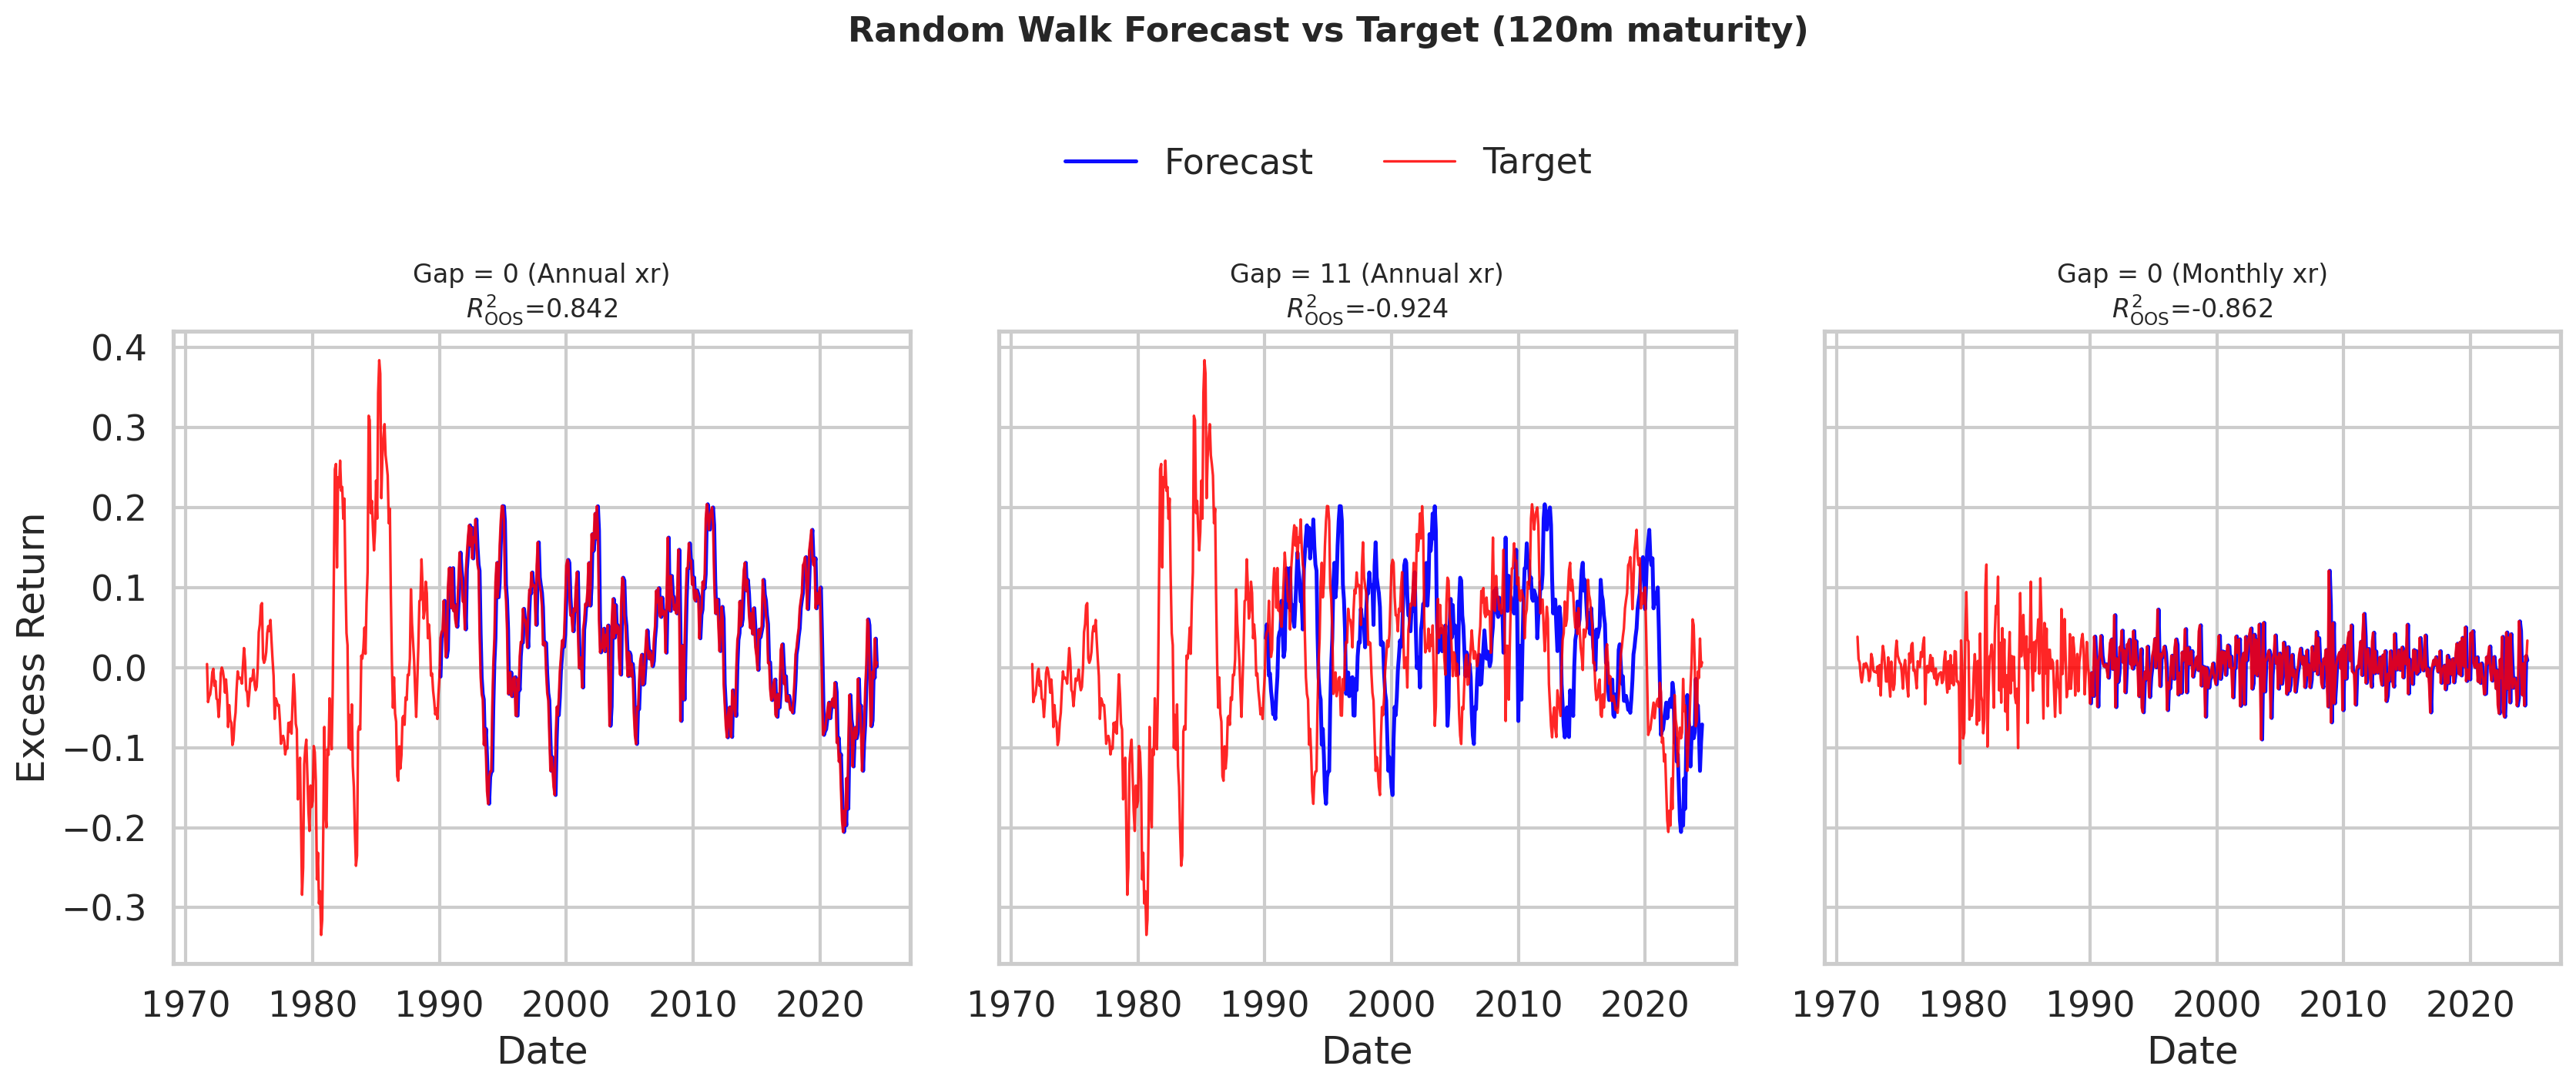

In [16]:
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid', context='talk')

plot_order = ['gap=0 (annual xr)', 'gap=11 (annual xr)', 'monthly_xr (gap=0)']
plot_titles = ['Gap = 0 (Annual xr)', 'Gap = 11 (Annual xr)', 'Gap = 0 (Monthly xr)']

# Taller figure + higher DPI + manual spacing to keep suptitle/legend/subtitles separate
fig, axes = plt.subplots(1, 3, figsize=(20, 7.6), dpi=200, sharey=True, constrained_layout=False)
fig.subplots_adjust(top=0.70, bottom=0.16, wspace=0.12)

for ax, key, panel_title in zip(axes, plot_order, plot_titles):
    res = rw_results[key]
    date_index = pd.DatetimeIndex(res['dates'])

    ax.plot(date_index, res['y_hat'], color='blue', linewidth=1.8, alpha=0.95, label='Forecast')
    ax.plot(date_index, res['y_target'], color='red', linewidth=1.2, alpha=0.85, label='Target')

    ax.set_title(f"{panel_title}\n$R^2_{{\mathrm{{OOS}}}}$={res['r2']:.3f}", fontsize=12)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=0)
    ax.set_xlabel('Date')

axes[0].set_ylabel('Excess Return')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.885))
fig.suptitle(
    f"Random Walk Forecast vs Target ({rw_maturity}m maturity)",
    fontsize=16,
    fontweight='bold',
    y=0.97,
)

plt.show()

# 3. Generate XGB vs. RW experiment

The following cell generates `Table X`: Out-of-sample R2 for XGBoost across return specifications and gap configurations (1971–
2018).

In [19]:
import pandas as pd
import numpy as np
from itertools import product
from models.tree import FwdFredTreeEnsemble1D
from models.base import RandomWalkModel
import utils.window_utils as wu
import utils.base_utils as bu
import os

# ── Configuration ────────────────────────────────────────────────────────────
OOS_START      = pd.Timestamp('1990-01-31')
REFIT_FREQ     = 1          
GAP_LIST       = [1, 3, 5, 11]
MATURITIES     = [120]        # months → 2,3,4,5,7,10 yr
DATASET        = "KR"         # label for output
SAMPLE_END     = "2025-06"    # informational label only

# ── Models ───────────────────────────────────────────────────────────────────
def make_models():
    models = {
        "XGB (Fwd)"      : FwdFredTreeEnsemble1D(estimator="xgb", include_fred=False, tune_every=60),
        "XGB (Macro+Fwd)": FwdFredTreeEnsemble1D(estimator="xgb", include_fred=True, tune_every=60),
        "RW"             : RandomWalkModel(),
    }
    return models

# ── Core runner ──────────────────────────────────────────────────────────────
def run_gap_experiment(xr_df, X, oos_start=OOS_START,
                       gap_list=GAP_LIST, maturities=MATURITIES,
                       refit_freq=REFIT_FREQ, live_save_path=f"gap_updated_and_limited_experiment_{DATASET}_live.csv"):
    """
    Returns a DataFrame with columns:
        maturity | model | gap | r2 | pval
    and a derived column:
        macro_gain  = R2(Macro+Fwd) - R2(Fwd)   [same gap & maturity]
    """
    records = []
    
    for mat in maturities:
        mat_label = str(mat)
        y = xr_df[mat_label].values
        dates = xr_df.index

        print(f"\n--- Running models for maturity {mat}m ---")
        
        gaps_to_run = [0] + [g for g in gap_list if g != 0]

        for gap in gaps_to_run:
            models = make_models()
            
            for model_name, model in models.items():
                y_hat = wu.expanding_window(
                    model, X, y, dates,
                    oos_start=oos_start,
                    gap=gap,
                    refit_freq=refit_freq,
                )
                r2   = wu.oos_r2(y, y_hat, gap=gap)
                pval = bu.RSZ_Signif(y, y_hat, gap=gap)

                records.append(dict(
                    maturity    = mat,
                    model       = model_name,
                    gap         = gap,
                    r2          = r2,
                    pval        = pval,
                ))
                if live_save_path:
                    pd.DataFrame(records).to_csv(live_save_path, index=False)
                    
            print(f"  mat={mat}m  gap={gap}  done")

    df = pd.DataFrame(records)

    # ── Macro gain ──────────────────────────────────────────────────────────
    fwd   = df[df.model == "XGB (Fwd)"]   [["maturity","gap","r2"]].rename(columns={"r2":"r2_fwd"})
    macro = df[df.model == "XGB (Macro+Fwd)"][["maturity","gap","r2"]].rename(columns={"r2":"r2_macro"})
    gain  = fwd.merge(macro, on=["maturity","gap"])
    gain["macro_gain"] = gain["r2_macro"] - gain["r2_fwd"]

    df = df.merge(gain[["maturity","gap","macro_gain"]], on=["maturity","gap"], how="left")
    return df


# ── Formatting helpers ───────────────────────────────────────────────────────
def _fmt_r2(r2, pval, thresholds=(0.01, 0.05, 0.10)):
    """Format R² as percentage with significance stars (only for positive R²)."""
    stars = ""
    if r2 > 0:  # Only apply significance stars if R² is positive
        if pval < thresholds[0]:  stars = "***"
        elif pval < thresholds[1]: stars = "**"
        elif pval < thresholds[2]: stars = "*"
    return f"{r2*100:.1f}{stars}"

def _fmt_gain(gain):
    """Macro gain in pp, bracketed."""
    return f"[{gain*100:+.1f}]"


def make_latex_table(df, maturity=120, caption=None, label=None):
    """
    Single-maturity table (matches your existing Table 1 layout).
    Rows: models. Columns: gaps. Macro gain shown in brackets below XGB rows.
    """
    sub   = df[df.maturity.astype(str) == str(maturity)].copy()
    gaps  = sorted(sub.gap.unique())
    models_order = ["XGB (Fwd)", "XGB (Macro+Fwd)", "RW"]

    col_spec = "l" + "c" * len(gaps)
    gap_header = " & ".join(f"Gap={g}" for g in gaps)
    mat_yr = int(maturity) // 12

    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\small",
        rf"\caption{{{caption or f'Gap experiment, {mat_yr}Y maturity, {DATASET} yields, 1971–{SAMPLE_END}'}}}",
        rf"\label{{{label or f'tab:gap_{mat_yr}y'}}}",
        rf"\begin{{tabular}}{{{col_spec}}}",
        r"\toprule",
        rf" & \multicolumn{{{len(gaps)}}}{{c}}{{Overlapping annual returns}} \\",
        rf"\cmidrule(lr){{2-{len(gaps)+1}}}",
        f" & {gap_header} \\",
        r"\midrule",
    ]

    for model_name in models_order:
        row_df = sub[sub.model == model_name]
        cells  = []
        gains  = []

        for g in gaps:
            r = row_df[row_df.gap == g].iloc[0]
            cells.append(_fmt_r2(r.r2, r.pval))
            if model_name != "RW":
                gains.append(_fmt_gain(r.macro_gain))

        lines.append(f"{model_name} & {' & '.join(cells)} \\")

        # Macro gain row (indented label, no stars)
        if model_name == "XGB (Macro+Fwd)":
            lines.append(
                rf"\quad $\Delta$Macro & {' & '.join(gains)} \\"
            )

        if model_name == "XGB (Fwd)":
            lines.append(r"\midrule")

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        (r"\begin{tablenotes}\footnotesize"
         r"\item $R^2_{OOS}$ in \%. Stars from Clark--West (2007): "
         r"$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$. "
         r"Stars only shown for positive $R^2_{OOS}$. "
         r"\Delta$Macro $= R^2(\text{Macro+Fwd}) - R^2(\text{Fwd})$ "
         r"at each gap value. "
         rf"KR yield curve, tune\_every=60."
         r"\end{tablenotes}"),
        r"\end{table}",
    ]
    return "\n".join(lines)


def make_latex_table_all_maturities(df, caption=None, label=None):
    """
    Multi-maturity summary: one panel per model, rows = maturities,
    cols = gaps. Macro gain panel appended at the bottom.
    """
    gaps     = sorted(df.gap.unique())
    mats     = sorted(df.maturity.unique())
    mat_lbls = [f"{int(m)//12}Y" for m in mats]

    col_spec   = "l" + "c" * len(gaps)
    gap_header = " & ".join(f"Gap={g}" for g in gaps)
    n_gap      = len(gaps)

    panels = {
        r"A. XGB (Forward only)"   : "XGB (Fwd)",
        r"B. XGB (Macro+Forward)"  : "XGB (Macro+Fwd)",
        r"C. Random walk"          : "RW",
        r"D. Macro gain $[\Delta]$": None,   # derived
    }

    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\small",
        rf"\caption{{{caption or f'Gap experiment, all maturities, {DATASET} yields, 1971–{SAMPLE_END}'}}}",
        rf"\label{{{label or 'tab:gap_all_maturities'}}}",
        rf"\begin{{tabular}}{{{col_spec}}}",
        r"\toprule",
        rf" & \multicolumn{{{n_gap}}}{{c}}{{Overlapping annual returns}} \\",
        rf"\cmidrule(lr){{2-{n_gap+1}}}",
        f" & {gap_header} \\",
    ]

    for panel_label, model_key in panels.items():
        lines += [r"\midrule", rf"\textit{{{panel_label}}} \\"]

        for mat, mat_lbl in zip(mats, mat_lbls):
            sub = df[df.maturity == mat]

            if model_key is not None:
                row_df = sub[sub.model == model_key]
                cells  = []
                for g in gaps:
                    r = row_df[row_df.gap == g].iloc[0]
                    cells.append(_fmt_r2(r.r2, r.pval))
            else:
                # Macro gain panel
                cells = []
                for g in gaps:
                    gain_val = sub[sub.gap == g]["macro_gain"].iloc[0]
                    cells.append(_fmt_gain(gain_val))

            lines.append(f"{mat_lbl} & {' & '.join(cells)} \\")

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        (r"\begin{tablenotes}\footnotesize"
         r"\item $R^2_{OOS}$ in \%. Stars from Clark--West (2007): "
         r"$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$. "
         r"Stars only shown for positive $R^2_{OOS}$. "
         r"Panel D: $\Delta = R^2(\text{Macro+Fwd}) - R^2(\text{Fwd})$ "
         r"in percentage points, no significance test. "
         rf"KR yield curve, tune\_every=60."
         r"\end{tablenotes}"),
        r"\end{table}",
    ]
    return "\n".join(lines)


# ── Entry point ──────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # Make sure the target tables dir exists
    import os
    os.makedirs('tables', exist_ok=True)

    print("Running gap experiment …")
    results = run_gap_experiment(xr, X)

    # Save raw results for inspection / reuse
    results.to_csv(f"gap_experiment_{DATASET}.csv", index=False)

    # Single-maturity table (120m, matches your existing Table 1)
    tex_single = make_latex_table(results, maturity=120)
    with open("tables/gap_120m.tex", "w") as f:
        f.write(tex_single)

    # All-maturities table
    tex_all = make_latex_table_all_maturities(results)
    with open("tables/gap_all_maturities.tex", "w") as f:
        f.write(tex_all)

    print("Done. Tables written to tables/")
    print("\n--- 120m single-maturity table preview ---\n")
    print(tex_single)

Running gap experiment …

--- Running models for maturity 120m ---


  mat=120m  gap=0  done


  mat=120m  gap=1  done


  mat=120m  gap=3  done


  mat=120m  gap=5  done


  mat=120m  gap=11  done
Done. Tables written to tables/

--- 120m single-maturity table preview ---

\begin{table}[ht]
\centering
\small
\caption{Gap experiment, 10Y maturity, KR yields, 1971–2025-06}
\label{tab:gap_10y}
\begin{tabular}{lccccc}
\toprule
 & \multicolumn{5}{c}{Overlapping annual returns} \\
\cmidrule(lr){2-6}
 & Gap=0 & Gap=1 & Gap=3 & Gap=5 & Gap=11 \
\midrule
XGB (Fwd) & 43.0*** & 24.3*** & 3.1*** & -14.2 & -52.4 \
\midrule
XGB (Macro+Fwd) & 54.5*** & 43.4*** & 24.7*** & 17.0*** & -13.7 \
\quad $\Delta$Macro & [+11.6] & [+19.1] & [+21.6] & [+31.3] & [+38.6] \\
RW & 84.2*** & 66.1*** & 34.5*** & 4.3*** & -86.9 \
\bottomrule
\end{tabular}
\begin{tablenotes}\footnotesize\item $R^2_{OOS}$ in \%. Stars from Clark--West (2007): $^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$. Stars only shown for positive $R^2_{OOS}$. \Delta$Macro $= R^2(\text{Macro+Fwd}) - R^2(\text{Fwd})$ at each gap value. KR yield curve, tune\_every=60.\end{tablenotes}
\end{table}


<Axes: xlabel='date'>

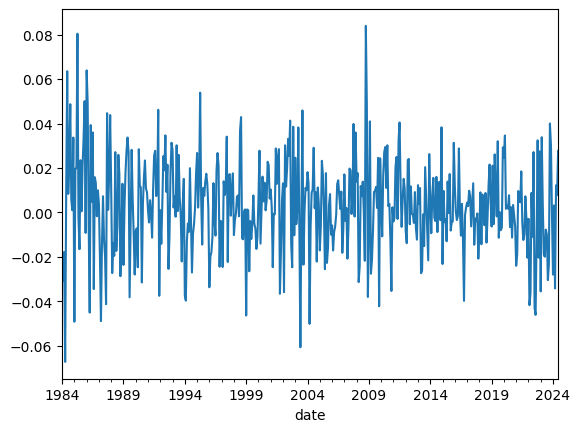

In [13]:
monthly_xr[monthly_xr.index > '1984']['84'].plot()
# xr[xr.index > '1984']['84'].plot()

# Generate summary statistics for excess returns:

In [11]:
import pandas as pd
import numpy as np

MATURITIES = [str(m) for m in range(24, 121, 12)]


def build_return_stats_table(
    df: pd.DataFrame,
    maturities: list[str],
    *,
    annualize_mean_std: bool,
    periods_per_year: float = 12.0,
    kurtosis_mode: str = "raw",  # "raw" => normal=3, "excess" => normal=0
    scale_to_percent: bool = True,
) -> pd.DataFrame:
    cols = [m for m in maturities if m in df.columns]
    if not cols:
        raise ValueError("None of the requested maturities were found in the dataframe columns.")

    table = pd.DataFrame(index=["Mean", "Std", "Skew", "Kurt", "ACF"], columns=cols, dtype=float)

    for m in cols:
        s = pd.to_numeric(df[m], errors="coerce").dropna()
        mean_val = s.mean()
        std_val = s.std()

        if annualize_mean_std:
            mean_val *= periods_per_year
            std_val *= np.sqrt(periods_per_year)

        if scale_to_percent:
            mean_val *= 100.0
            std_val *= 100.0

        kurt_val = s.kurt()  # pandas reports excess kurtosis
        if kurtosis_mode == "raw":
            kurt_val += 3.0

        table.loc["Mean", m] = mean_val
        table.loc["Std", m] = std_val
        table.loc["Skew", m] = s.skew()
        table.loc["Kurt", m] = kurt_val
        table.loc["ACF", m] = s.autocorr(lag=1)

    return table.round(2)


# Non-overlapping (monthly holding period) excess returns: annualize mean/std.
monthly_xr_table = build_return_stats_table(
    monthly_xr,
    MATURITIES,
    annualize_mean_std=True,
    periods_per_year=12.0,
    kurtosis_mode="raw",
)

# Overlapping (12-month holding period) excess returns: already 12-month returns,
# so do not annualize mean/std again.
xr_table = build_return_stats_table(
    xr,
    MATURITIES,
    annualize_mean_std=False,
    periods_per_year=12.0,
    kurtosis_mode="raw",
)

monthly_xr_table, xr_table

(        24    36    48    60    72    84    96   108   120
 Mean  1.25  1.90  2.36  2.79  3.19  3.45  3.73  4.06  4.44
 Std   1.94  3.07  4.21  5.24  6.25  7.26  8.21  9.09  9.97
 Skew  0.12 -0.03 -0.06 -0.05 -0.01  0.06  0.11  0.13  0.13
 Kurt  4.16  3.72  3.61  3.64  3.70  3.84  4.08  4.27  4.35
 ACF   0.22  0.17  0.14  0.12  0.10  0.09  0.07  0.07  0.07,
         24    36    48    60    72    84    96   108   120
 Mean  0.63  1.23  1.82  2.24  2.69  3.01  3.28  3.59  3.98
 Std   1.47  2.73  3.85  4.86  5.84  6.74  7.61  8.49  9.32
 Skew  0.19  0.06  0.07  0.09  0.15  0.17  0.20  0.25  0.26
 Kurt  3.47  3.27  3.24  3.21  3.32  3.38  3.44  3.54  3.55
 ACF   0.96  0.95  0.94  0.94  0.93  0.93  0.92  0.92  0.92)